In [119]:
from fitburst.backend import general
import fitburst.routines as rt
import numpy as np
import scipy.special as ss

import os
import oscfar as ocf
import matplotlib.pyplot as plt

In [120]:
npz_file = os.path.expanduser("temp.npz")
reader = ocf.npz_reader(npz_file)

In [121]:
res = ocf.utils.FitburstResultsReader("results_fitburst_305046164.json")

In [122]:
writer = ocf.npz_writer(reader)
writer.update_burst_parameters(**res.get_model_parameters())

In [123]:
writer.save("temp.npz")

Saving file at temp.npz...
Saved file at temp.npz successfully.


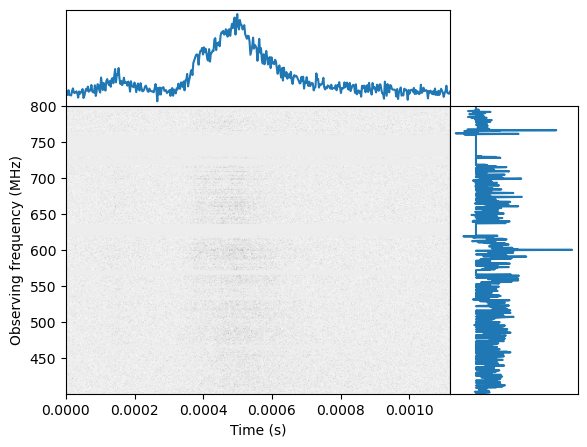

In [124]:
plot = ocf.waterfall_axes()
plot.plot(reader)
plot.show()

In [125]:
freqs = reader.freqs
times = reader.times

In [126]:
len(freqs), len(times)

(1024, 438)

In [127]:
def downsample_tile(orig, factors):
    if len(orig.shape) != len(factors):
        raise ValueError(
            f"Mismatch between number of factors and array shape: {len(factors)} vs {len(orig.shape)}"
        )
    shape_new = []
    pos = []
    for i, (f, s) in enumerate(zip(factors, orig.shape)):
        shape_new.append(s // f)
        shape_new.append(f)
        pos.append(i * 2 + 1)

    return np.mean(orig.reshape(shape_new), axis=tuple(pos))

In [128]:
t = np.tile(times, [len(freqs), 1])
t = times

In [129]:
t.shape

(438,)

In [130]:
if t.ndim == 1:
    freq_dep_time = False
elif t.ndim == 2:
    freq_dep_time = True

In [131]:
freq_dep_time

False

In [132]:
current_amplitudes = np.array(reader.burst_parameters["amplitude"])
current_arrival_times = np.array(reader.burst_parameters["arrival_time"])
current_dm = reader.burst_parameters["dm"][0]
current_ref_freq = np.array(reader.burst_parameters["ref_freq"], dtype=float)
current_sc_idx = reader.burst_parameters["scattering_index"][0]
current_sc_time = reader.burst_parameters["scattering_timescale"][0]
current_sp_idx = np.array(reader.burst_parameters["spectral_index"])
current_sp_run = np.array(reader.burst_parameters["spectral_running"])
current_widths = np.array(reader.burst_parameters["burst_width"])


# current_ref_freq = np.array(current_ref_freq, dtype=float)
num_components = len(current_arrival_times)

In [133]:
num_components

2

# Testing v2


How the model is defined

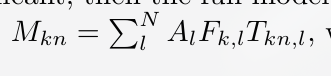

Amplitude definition:

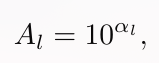

Spectrum computation:

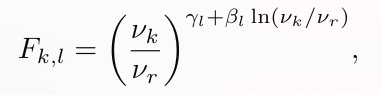

Time profile computation:

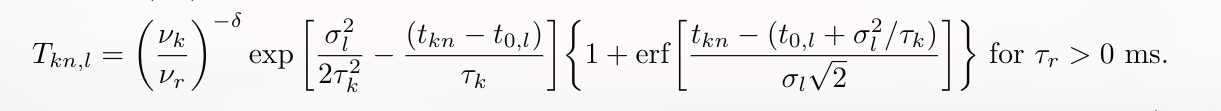
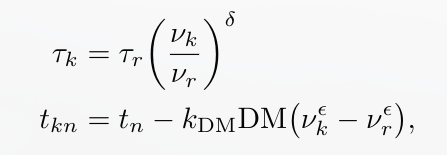
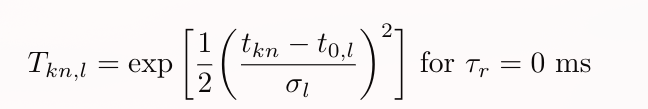


In [134]:
upsample_factor_freq = 2
upsample_factor_time = 2

current_freq_arr = rt.manipulate.upsample_1d(
    freqs, reader.res_freq, upsample_factor_freq
)

current_times_arr = t
if freq_dep_time:
    current_times_arr = np.repeat(current_times_arr, upsample_factor_freq, axis=0)
current_times_arr = rt.manipulate.upsample_1d(
    current_times_arr.T, reader.res_time, upsample_factor_time
).T

In [135]:
freq_ratio = current_freq_arr[:, None] / current_ref_freq
exp = np.array(current_sp_idx) + np.array(current_sp_run) * np.log(freq_ratio)
f_kl = np.power(freq_ratio, exp)

In [136]:
# so t_0,l are the arrival times from the model, t_n the times from the model, t_kn the times with dispersion removed.
# instead what can be done is do arrival time + dm stuff and then t_n - (all the previous stuff) to basically do t_kn - t_0,l

# t_0,l is a a (l,) shaped array, t_n is a (n,) shaped array unless we have frequency dependent times in which case it becomes (k,n)

In [137]:
dm_delay = rt.ism.compute_time_dm_delay(
    current_dm,
    general["constants"]["dispersion"],
    -2,
    current_freq_arr[:, None],
    np.array(current_ref_freq),
)

In [138]:
time_arr = current_arrival_times + dm_delay

In [139]:
time_arr.shape

(2048, 2)

In [140]:
current_times_arr.shape

(876,)

In [141]:
current_times_arr = (
    np.tile(current_times_arr[:, :, np.newaxis], (1, 1, num_components))
    - time_arr[:, None, :]
)

# this tiling depends on if 2d or 1d time array

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
tau_k = current_sc_time * np.pow(freq_ratio, current_sc_idx)

In [ ]:
def compute_profile_pbf(
    time: float,
    toa: float,
    width: float,
    freq: float,
    ref_freq: float,
    sc_time_ref: float,
    sc_index: float = -4.0,
    normalize: bool = False,
) -> float:
    freq_ratio = freq[:, None] / ref_freq  # (k,l) shape
    sc_time = sc_time_ref * (freq_ratio**sc_index)

    z = (time - toa) / width  # (k,n,l) shape
    ratio = (
        width / sc_time
    )  # (k,l) shape (no time dep only frequency so tile up the array)
    ratio = np.tile(ratio[:, np.newaxis, :], (1, time.shape[1], 1))  # (k,n,l) shape

    arg1 = (ratio - z) / np.sqrt(2)  # (k,n,l) shape

    # if normalized then (k,n,l) shape due to the ratio's shape (only a frequency dependence, no time)
    # if not normalized doing sc_time_ref/sc_time will result in a (k,l) shape so we need to tile it up again to (k,n,l)
    amp_term = (
        np.sqrt(np.pi / 2) * ratio
        if normalize
        else np.tile((sc_time_ref / sc_time)[:, np.newaxis, :], (1, time.shape[1], 1))
    )

    profile = np.empty(time.shape, dtype=float)

    r1, r2 = identify_pbf_regime(arg1)

    if r1 is not None:
        profile[..., r1] = (
            amp_term * np.exp(-0.5 * z[..., r1] ** 2) * ss.erfcx(arg1[..., r1])
        )
    if r2 is not None:
        arg2 = (ratio / 2 - z[..., r2]) * ratio
        profile[..., r2] = amp_term * np.exp(arg2) * ss.erfc(arg1[..., r2])

    return profile
    # print(z.shape, ratio.shape, temp.shape, temp[0,0,0]==ratio[0,0], temp[0,500,1]==ratio[0,1])

In [ ]:
profile = compute_profile_pbf(
    current_times_arr,
    0.0,
    current_widths,
    current_freq_arr,
    current_ref_freq,
    current_sc_time,
    current_sc_idx,
    False,
)

In [ ]:
timeprof_per_component = downsample_tile(
    profile, (upsample_factor_freq, upsample_factor_time, 1)
)

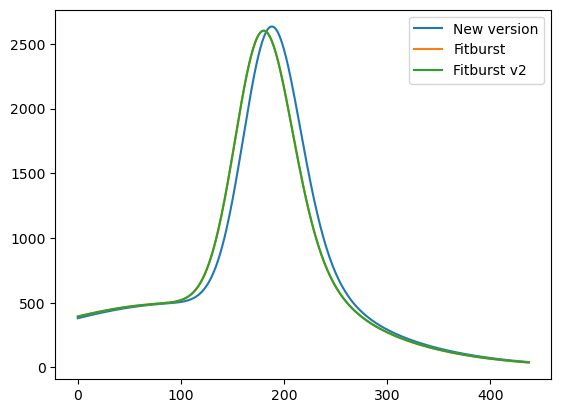

In [152]:
plt.plot(timeprof_per_component.sum(2).sum(0), label="New version")
plt.plot(modeler.timeprof_per_component.sum(2).sum(0), label="Fitburst")
plt.plot(modeler_v2.timeprof_per_component.sum(2).sum(0), label="Fitburst v2")
plt.legend()
plt.show()

(array([  5291.,   8528.,  11552.,  18493., 681822., 127105.,  17443.,
         11919.,   9100.,   5771.]),
 array([-0.62937225, -0.50288183, -0.37639141, -0.24990099, -0.12341057,
         0.00307985,  0.12957027,  0.25606069,  0.3825511 ,  0.50904152,
         0.63553194]),
 <BarContainer object of 10 artists>)

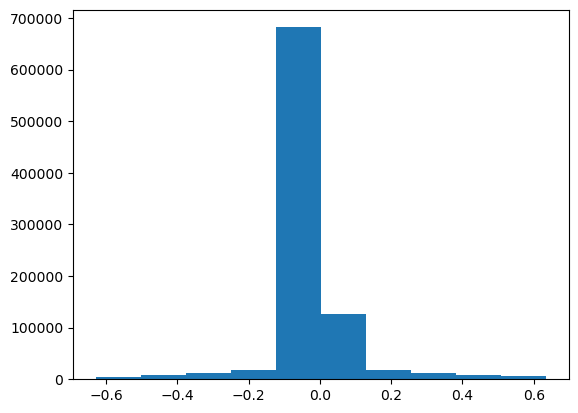

In [ ]:
plt.hist((modeler.timeprof_per_component - timeprof_per_component).flatten())

In [ ]:
# Small fitburst loop
fitburst_prof = np.empty(current_times_arr.shape)
for i in range(len(freqs)):
    for c in range(num_components):
        idf = i
        idc = c

        f_t = t[idf]
        up_f = rt.manipulate.upsample_1d(
            [freqs[idf]], reader.res_freq, upsample_factor_freq
        )
        up_t = rt.manipulate.upsample_1d(f_t, reader.res_time, upsample_factor_time)

        a_tvf = current_arrival_times[idc] + rt.ism.compute_time_dm_delay(
            0 + current_dm,
            general["constants"]["dispersion"],
            -2,
            up_f,
            current_ref_freq[idc],
        )

        new_t = (
            up_t - a_tvf[:, None]
        )  # (freq, time) or really (upsampling factor freq, upsampled time length)

        sc = current_sc_time * (up_f[:, None] / current_ref_freq[idc]) ** current_sc_idx

        ratio = current_widths[idc] / sc
        z = (new_t - 0) / current_widths[idc]
        arg1 = (ratio - z) / np.sqrt(2)

        amp1 = current_sc_time / sc

        r1, r2 = identify_pbf_regime(arg1)

        prof1 = np.empty(new_t.shape)

        if r1 is not None:
            prof1[..., r1] = (
                amp1 * np.exp(-0.5 * z[..., r1] ** 2) * ss.erfcx(arg1[..., r1])
            )

        if r2 is not None:
            arg2 = (ratio / 2 - z[..., r2]) * ratio
            prof1[..., r2] = amp1 * np.exp(arg2) * ss.erfc(arg1[..., r2])

        fitburst_prof[i, :, c] = prof1[0]
        fitburst_prof[i + 1, :, c] = prof1[1]

In [ ]:
idf = 0
idc = 0

f_t = t[idf]
up_f = rt.manipulate.upsample_1d([freqs[idf]], reader.res_freq, upsample_factor_freq)
up_t = rt.manipulate.upsample_1d(f_t, reader.res_time, upsample_factor_time)

a_tvf = current_arrival_times[idc] + rt.ism.compute_time_dm_delay(
    0 + current_dm, general["constants"]["dispersion"], -2, up_f, current_ref_freq[idc]
)

new_t = (
    up_t - a_tvf[:, None]
)  # (freq, time) or really (upsampling factor freq, upsampled time length)

In [ ]:
sc = current_sc_time * (up_f[:, None] / current_ref_freq[idc]) ** current_sc_idx

In [ ]:
ratio = current_widths[idc] / sc
z = (new_t - 0) / current_widths[idc]
arg1 = (ratio - z) / np.sqrt(2)

amp1 = current_sc_time / sc

r1, r2 = identify_pbf_regime(arg1)

prof1 = np.empty(new_t.shape)

if r1 is not None:
    prof1[..., r1] = amp1 * np.exp(-0.5 * z[..., r1] ** 2) * ss.erfcx(arg1[..., r1])

if r2 is not None:
    arg2 = (ratio / 2 - z[..., r2]) * ratio
    prof1[..., r2] = amp1 * np.exp(arg2) * ss.erfc(arg1[..., r2])

In [ ]:
sc2 = current_sc_time * freq_ratio**current_sc_idx
z2 = (current_times_arr - 0) / current_widths
ratio2 = current_widths / sc2
ratio2 = np.tile(ratio2[:, np.newaxis, :], (1, current_times_arr.shape[1], 1))
arg12 = (ratio2 - z2) / np.sqrt(2)
amp2 = np.tile(
    (current_sc_time / sc2)[:, np.newaxis, :], (1, current_times_arr.shape[1], 1)
)

r21, r22 = identify_pbf_regime(arg12)

prof2 = np.empty(current_times_arr.shape)

In [ ]:
if r1 is not None:
    prof2[..., r1] = amp2 * np.exp(-0.5 * z2[..., r1] ** 2) * ss.erfcx(arg12[..., r1])
if r2 is not None:
    arg2 = (ratio / 2 - z[..., r2]) * ratio
    prof2[..., r2] = amp2 * np.exp(arg2) * ss.erfc(arg1[..., r2])


In [ ]:
prof2.shape, fitburst_prof.shape

((2048, 876, 2), (2048, 876, 2))

In [ ]:
ratio2[idf : idf + 2, :, 0].mean(1) - ratio.flatten()

array([-5.55111512e-17,  0.00000000e+00])

In [ ]:
# np.all(z == z2[0:2,:,0])

ratio.flatten() == ratio2[0:2, :, 0].mean(1)

array([False,  True])

In [ ]:
# np.all(prof1 == prof2[0:2, :, 0])

diff = prof2[0:2, :, 0] - prof1

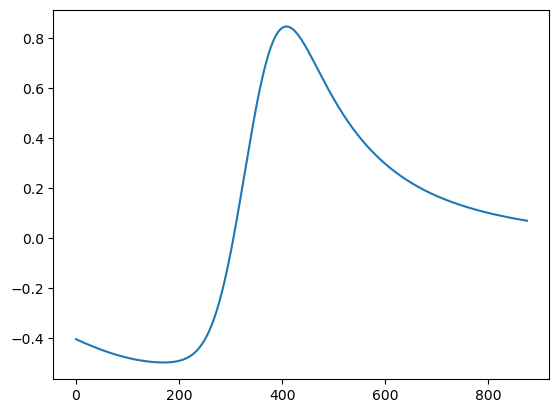

In [ ]:
plt.plot(diff[0])

In [ ]:
current_sc_time * (freq_ratio**current_sc_idx)[0:2, idc]

array([0.00021913, 0.0002187 ])

In [ ]:
prof = modeler.compute_profile(
    new_t,
    0.0,
    current_sc_time,
    current_sc_idx,
    current_widths[idc],
    up_f[:, None],
    current_ref_freq[idc],
    False,
)

In [ ]:
# prof = rt.manipulate.downsample_1d(prof.mean(0), upsample_factor_freq)

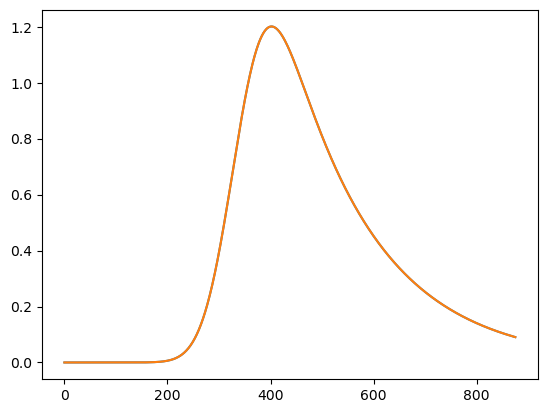

In [ ]:
plt.plot(prof[0])
plt.plot(profile[idf * 2, :, idc])

(array([793.,   1.,   1.,   2.,   2.,   2.,   2.,   4.,   7.,  62.]),
 array([0.00000000e+00, 5.44792630e-08, 1.08958526e-07, 1.63437789e-07,
        2.17917052e-07, 2.72396315e-07, 3.26875578e-07, 3.81354841e-07,
        4.35834104e-07, 4.90313367e-07, 5.44792630e-07]),
 <BarContainer object of 10 artists>)

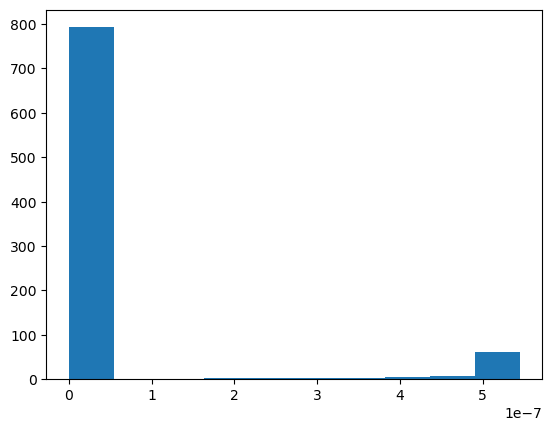

In [ ]:
plt.hist(prof[0] - profile[idf * 2, :, idc])

In [ ]:
prof[0] == profile[0, :, 0]

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [ ]:
# current_times_arr.shape, tau_k.shape

((2048, 876, 2), (2048, 2))

In [ ]:
# current_times_arr / tau_k[:, None, :]

array([[[ -1.97051412,  -0.85962602],
        [ -1.96467272,  -0.85378462],
        [ -1.95883133,  -0.84794322],
        ...,
        [  3.1290277 ,   4.2399158 ],
        [  3.1348691 ,   4.2457572 ],
        [  3.1407105 ,   4.2515986 ]],

       [[ -1.97452006,  -0.86146225],
        [ -1.96866725,  -0.85560945],
        [ -1.96281444,  -0.84975664],
        ...,
        [  3.1349818 ,   4.24803961],
        [  3.14083461,   4.25389242],
        [  3.14668742,   4.25974523]],

       [[ -1.97853201,  -0.86330133],
        [ -1.97266778,  -0.85743709],
        [ -1.96680354,  -0.85157286],
        ...,
        [  3.14094447,   4.25617516],
        [  3.14680871,   4.26203939],
        [  3.15267294,   4.26790363]],

       ...,

       [[-33.31178734, -15.61550141],
        [-33.21873469, -15.52244876],
        [-33.12568205, -15.42939612],
        ...,
        [ 47.92317234,  65.61945827],
        [ 48.01622499,  65.71251091],
        [ 48.10927763,  65.80556356]],

       [[-33.34

# Testing Stuff v1


## 1. Create upsampled arrays for frequencies and time


In [ ]:
current_freq_arr = rt.manipulate.upsample_1d(freqs, reader.res_freq, 2)

In [ ]:
new_t = t
if freq_dep_time:
    new_t = rt.manipulate.upsample_1d(new_t, reader.res_freq, 2).T
new_t = rt.manipulate.upsample_1d(new_t, reader.res_time, 2).T

current_times = new_t

## 2. Compute arrival times


In [ ]:
dm_delay = rt.ism.compute_time_dm_delay(
    current_dm, general["constants"]["dispersion"], -2, current_freq_arr, 400
)

arrival_time_vs_freq = np.tile(
    np.array(current_arrival_times)[:, np.newaxis], (1, *current_freq_arr.shape)
) + np.tile(dm_delay[np.newaxis, :], (num_components, 1))

## 3. Calculate time relative


In [ ]:
if freq_dep_time:
    current_times_arr = np.tile(
        current_times[np.newaxis, :, :], (num_components, 1, 1)
    ) - np.tile(arrival_time_vs_freq[:, :, np.newaxis], (1, 1, current_times.shape[-1]))

else:
    arrival_time_vs_freq -= np.repeat(
        rt.ism.compute_time_dm_delay(
            0, general["constants"]["dispersion"], -2, freqs, 400
        ),
        2,
    )
    current_times_arr = np.tile(
        current_times[np.newaxis, np.newaxis, :], (*arrival_time_vs_freq.shape, 1)
    ) - np.tile(arrival_time_vs_freq[:, :, np.newaxis], (1, 1, len(current_times)))

In [ ]:
current_times_arr = np.transpose(current_times_arr, (1, 2, 0))

In [ ]:
current_times_arr.shape

(2048, 876, 2)

## 4. Save the time diff


In [ ]:
timediff_per_component = downsample_tile(current_times_arr, (2, 2, 1))

In [ ]:
timediff_per_component.shape

(1024, 438, 2)

## 5. Compute and store temporal profile


In [ ]:
def identify_pbf_regime(arg, threshold=-20.0):
    flag = arg > threshold  # if arg.ndim == 1 else np.all(arg > threshold)
    valid = np.flatnonzero(flag)
    invalid = np.flatnonzero(~flag) if valid.size < flag.size else None

    if valid.size == 0:
        valid = None
    elif (valid[-1] + 1 - valid[0]) == valid.size:
        valid = slice(valid[0], valid[-1] + 1)

    if invalid is not None and (invalid[-1] + 1 - invalid[0]) == invalid.size:
        invalid = slice(invalid[0], invalid[-1] + 1)

    return valid, invalid

In [ ]:
def compute_profile_pbf(
    time: float,
    toa: float,
    width: float,
    freq: float,
    ref_freq: float,
    sc_time_ref: float,
    sc_index: float = -4.0,
    normalize: bool = False,
):
    sc_time = sc_time_ref * (freq[:, None] / ref_freq) ** sc_index

    z = (
        (time - toa) / width
    )  # Normally a 1D array with all the times for one frequency and one component. Here a (num_freq, num_time, num_comp) array

    # ratio = (
    #     np.tile(np.array(width).reshape(1, len(width)), (len(sc_time), 1))
    #     / sc_time[:, None]
    # )  # Normally a constant for one frequency per component. Here a (num_freq, num_comp) array
    ratio = width / sc_time

    ratio = np.tile(ratio[:, np.newaxis, :], (1, time.shape[1], 1))

    arg1 = (
        (ratio - z) / np.sqrt(2)
    )  # Normally a 1D array with all the times for one frequency and one component. Here a (num_freq, num_time, num_comp) array

    amp_term = (
        np.sqrt(np.pi / 2) * ratio
        if normalize
        else np.tile(
            (current_sc_time / sc_time)[:, np.newaxis, :], (1, time.shape[1], 1)
        )
        # else np.tile(
        #     (sc_time_ref / sc_time).reshape(len(sc_time), 1, 1),
        #     (1, time.shape[1], time.shape[2]),
        # )
    )

    profile = np.empty(time.shape, dtype=float)

    r1, r2 = identify_pbf_regime(arg1)

    if r1 is not None:
        if not isinstance(r1, slice):
            r1 = np.unravel_index(r1, arg1.shape)
        profile[r1] = amp_term[r1] * np.exp(-0.5 * z[r1] ** 2) * ss.erfcx(arg1[r1])

    if r2 is not None:
        # if type(r2) != slice:
        if not isinstance(r2, slice):
            r2 = np.unravel_index(r2, arg1.shape)
        arg2 = (ratio / 2 - z) * ratio
        profile[r2] = amp_term[r2] * np.exp(arg2[r2]) * ss.erfc(arg1[r2])

    return profile

In [ ]:
def compute_profile_gaussian(
    values: float, mean: float, width: float, normalize: bool = False
):
    norm_factor = 1.0

    if normalize:
        norm_factor /= np.sqrt(2 * np.pi) / width

    profile = norm_factor * np.exp(-0.5 * ((values - mean) / width) ** 2)
    return profile

In [ ]:
def compute_profile(
    times: float,
    arrival_time: float,
    sc_time_ref: float,
    sc_index: float,
    width: float,
    freqs: float,
    ref_freq: float,
    is_folded: bool = False,
):
    times_copy = times.copy()
    if is_folded:
        res_time = np.diff(times_copy, axis=1)[:, 0]
        start = times[:, -1] + res_time
        stop = times[:, -1] + (res_time * times.shape[1])
        times_extended = np.linspace(start=start, stop=stop, num=times.shape[1], axis=1)
        times_copy = np.append(times, times_extended, axis=1)

    profile = np.zeros(times_copy.shape, dtype=float)
    sc_time = sc_time_ref * (freqs[:, None] / ref_freq) ** sc_index
    normalize = general.get("flags", False)
    if isinstance(type, dict):
        normalize = normalize.get("normalize_pbf", False)

    if np.any(sc_time > 0.0):
        threshold = (np.array(width) * -5).reshape(1, 1, len(width))
        mask = times_copy < threshold
        replacement_value = np.tile(
            (-5 * np.array(width)).reshape(1, 1, (len(width))),
            (times.shape[0], times.shape[1], 1),
        )

        times_copy[mask] = replacement_value[mask]

        profile = compute_profile_pbf(
            times_copy,
            arrival_time,
            width,
            freqs,
            ref_freq,
            sc_time_ref,
            sc_index=sc_index,
            normalize=normalize,
        )
    else:
        profile = compute_profile_gaussian(times_copy, arrival_time, width)

    return profile


#### Testing stuff around


In [ ]:
normalize = general.get("flags")
if isinstance(normalize, dict):
    normalize = normalize.get("normalize_pbf", False)

In [ ]:
sc_time = (
    current_sc_time * (current_freq_arr[:, None] / current_ref_freq) ** current_sc_idx
)  # (freq, n)

z = (current_times_arr - 0) / current_widths

ratio = current_widths / sc_time
arg1 = (np.tile(ratio[:, np.newaxis, :], (1, z.shape[1], 1)) - z) / np.sqrt(2)

In [ ]:
amp_term = np.sqrt(np.pi / 2) * ratio if normalize else current_sc_time / sc_time

In [ ]:
amp_term = np.tile(amp_term[:, np.newaxis, :], (1, current_times_arr.shape[1], 1))

In [ ]:
profile = np.empty(current_times_arr.shape)

In [ ]:
r1, r2 = identify_pbf_regime(arg1)

In [ ]:
if r1 is not None:
    if not isinstance(r1, slice):
        r1 = np.unravel_index(r1, arg1.shape)

    profile[r1] = amp_term[r1] * np.exp(-0.5 * z[r1] ** 2) * ss.erfcx(arg1[r1])

if r2 is not None:
    if not isinstance(r2, slice):
        r2 = np.unravel_index(r2, arg1.shape)

    tiled_ratio = np.tile(ratio[:, np.newaxis, :], (1, current_times_arr.shape[1], 1))
    arg2 = (tiled_ratio / 2 - z) * tiled_ratio
    profile[r2] = amp_term[r2] * np.exp(arg2[r2]) * ss.erfc(arg1[r2])

#### The actual computation


In [ ]:
profile = compute_profile(
    current_times_arr,
    0,
    current_sc_time,
    current_sc_idx,
    current_widths,
    current_freq_arr,
    current_ref_freq,
    False,
)

In [ ]:
timeprof_per_component = downsample_tile(profile, (2, 2, 1))

In [ ]:
timeprof_per_component.shape

(1024, 438, 2)

## 6. Compute spectral energy distribution


In [ ]:
def compute_spectrum_rpl(
    freqs: np.ndarray, freq_ref: float, sp_idx: float, sp_run: float
):
    sp_idx = np.array(sp_idx)
    sp_run = np.array(sp_run)
    log_freq = np.log(freqs[:, None] / freq_ref)
    exponent = log_freq * sp_idx[None, :] + log_freq**2 * sp_run[None, :]
    spectrum = np.exp(exponent)
    return spectrum

In [ ]:
test = compute_spectrum_rpl(
    current_freq_arr, current_ref_freq, current_sp_idx, current_sp_run
)

In [ ]:
profile_v2 = profile * np.tile(test[:, np.newaxis, :], (1, profile.shape[1], 1))

In [ ]:
profile_v2 = downsample_tile(profile_v2, (2, 2, 1))

## 7. Save model for each component in amplitude_per_component


In [ ]:
amplitude_per_component = np.tile(
    (
        compute_spectrum_rpl(
            np.array(freqs), current_ref_freq, current_sp_idx, current_sp_run
        )
        * (10 ** np.array(current_amplitudes))
    )[:, np.newaxis, :],
    (1, times.shape[-1], 1),
)

In [ ]:
spectrum = (10 ** np.array(current_amplitudes)) * profile_v2

In [ ]:
finalmodel = np.sum(spectrum, axis=2)

# Verify


In [ ]:
from fitburst.analysis.model import SpectrumModeler
import copy

In [ ]:
modeler = SpectrumModeler(
    freqs,
    t,
    dm_incoherent=0,
    factor_freq_upsample=2,
    factor_time_upsample=2,
    num_components=2,
    is_dedispersed=True,
    is_folded=False,
    scintillation=False,
    verbose=True,
)

In [ ]:
copy_param = copy.deepcopy(reader.burst_parameters)
copy_param["dm"] = [0]
copy_param["scattering_timescale"] = [copy_param["scattering_timescale"][0]]

In [ ]:
modeler.update_parameters(copy_param)

In [ ]:
modelfitburst = modeler.compute_model(data=reader.data_full)

ERROR MESSAGE BECAUSE IM GOING TO GIVE UP.
0.00000  -0.56361  0.00043   -4.00000  0.00022  0.00006 2.37841  -5.14895
0.00000  -1.44674  0.00019   -4.00000  0.00022  0.00035 7.77290  -11.71593


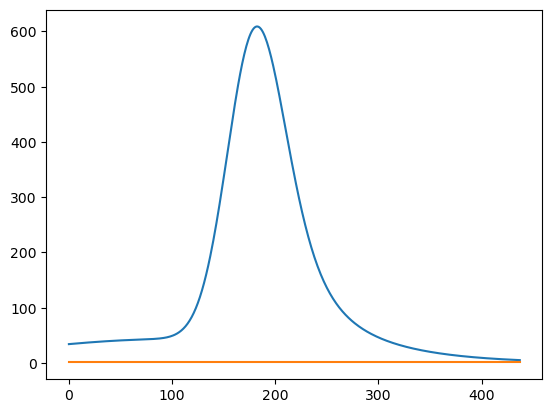

In [ ]:
plt.plot(modelfitburst.sum(0))
plt.plot(finalmodel.sum(0))

In [ ]:
import fitburst.utilities as ut

In [ ]:
reader.good_freq = np.sum(reader.data_weights, axis=1) != 0.0
reader.good_freq = np.sum(reader.data_full, axis=1) != 0.0

In [ ]:
bad_chans = ~reader.good_freq

In [ ]:
modelfitburst[bad_chans] = 0.0
# finalmodel[bad_chans] = 0.

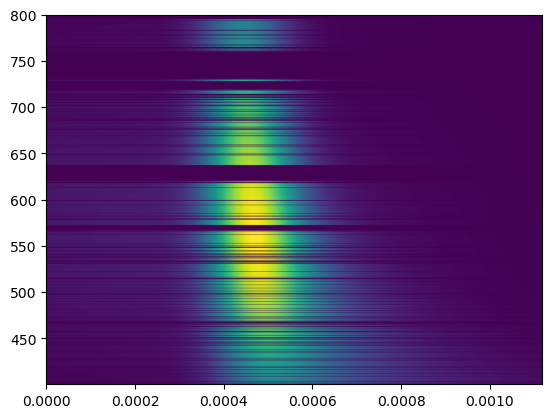

In [ ]:
plt.imshow(
    modelfitburst,
    aspect="auto",
    extent=[times[0], times[-1], freqs[0], freqs[-1]],
    origin="lower",
)

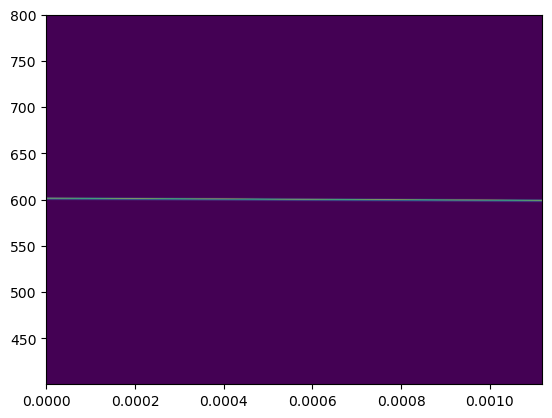

In [ ]:
plt.imshow(
    finalmodel,
    aspect="auto",
    extent=[times[0], times[-1], freqs[0], freqs[-1]],
    origin="lower",
)

In [ ]:
from fitburstmodel import FitBurstModel as sm

In [ ]:
modeler_v2 = sm(
    freqs,
    times,
    dm_incoherent=0,
    factor_freq_upsample=2,
    factor_time_upsample=2,
    num_components=2,
    is_dedispersed=True,
    is_folded=False,
    scintillation=False,
    verbose=True,
)

In [ ]:
modeler_v2.update_parameters(copy_param)

In [ ]:
modelfitburst_v2 = modeler_v2.compute_model(data=reader.data_full)
modelfitburst_v2[bad_chans] = 0.0

0.00000  -0.56361  0.00043   -4.00000  0.00022  0.00006 2.37841  -5.14895
0.00000  -1.44674  0.00019   -4.00000  0.00022  0.00035 7.77290  -11.71593


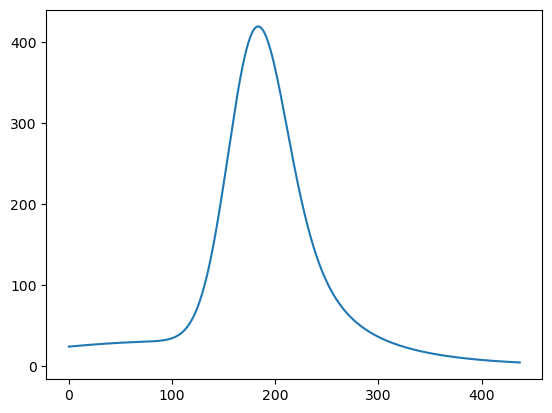

In [ ]:
plt.plot(modelfitburst_v2.sum(0))

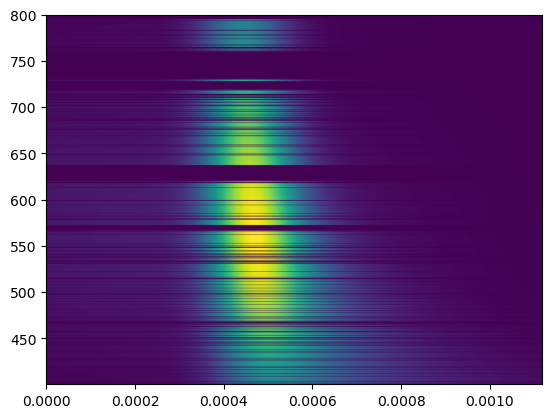

In [ ]:
plt.imshow(
    modelfitburst_v2,
    aspect="auto",
    extent=[times[0], times[-1], freqs[0], freqs[-1]],
    origin="lower",
)

In [ ]:
modelfitburst_v2 - modelfitburst

array([[-3.46944695e-18,  0.00000000e+00,  1.73472348e-18, ...,
        -3.60822483e-16,  9.02056208e-17, -1.31838984e-16],
       [-1.73472348e-18, -1.73472348e-18,  0.00000000e+00, ...,
        -2.70616862e-16,  1.80411242e-16, -8.67361738e-17],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(1024, 438))

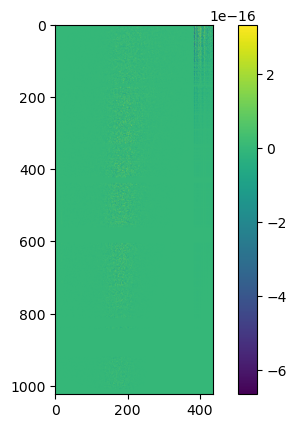

In [146]:
plt.imshow(modelfitburst_v2 - modelfitburst)
plt.colorbar()

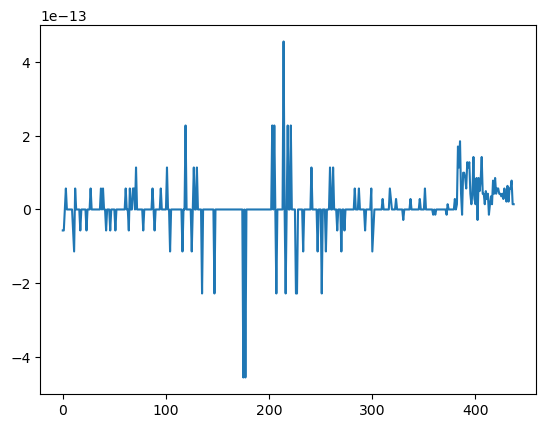

In [ ]:
plt.plot(
    modeler.timeprof_per_component.sum(2).sum(0)
    - modeler_v2.timeprof_per_component.sum(2).sum(0)
)

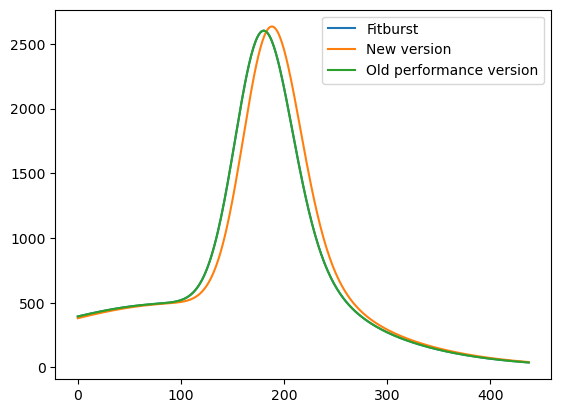

In [151]:
plt.plot(modeler.timeprof_per_component.sum(2).sum(0), label="Fitburst")
plt.plot(timeprof_per_component.sum(2).sum(0), label="New version")
plt.plot(
    modeler_v2.timeprof_per_component.sum(2).sum(0), label="Old performance version"
)

plt.legend()
plt.show()